# UMAP

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

_script_dir = str(Path(__file__).resolve().parent) if "__file__" in globals() else str(Path.cwd().resolve())
_sys_path_backup = list(sys.path)
sys.path = [p for p in sys.path if p not in ("", _script_dir)]
import umap as umap_pkg
sys.path = _sys_path_backup

## Define constants for the analysis

In [2]:
# Configuration
DATA_PATH    = Path("data/HR_data_2.csv") 
RANDOM_STATE = 42

# UMAP grid
N_NEIGHBORS_GRID = [5, 15, 30, 50]
MIN_DIST_GRID    = [0.0, 0.1, 0.3, 0.5]
N_PERMUTATIONS  = 500   # permutation test iterations

# Cohort - Season mapping 
COHORT_MAP = {
    "D1_1": "Winter",
    "D1_2": "Autumn",
    "D1_3": "Morning",
    "D1_4": "Evening",
    "D1_5": "Morning",
    "D1_6": "Evening",
}

# Colours
ROUND_COLORS = {1: "#534AB7", 2: "#1D9E75", 3: "#D85A30", 4: "#BA7517"}
PHASE_COLORS = {"phase1": "#378ADD", "phase2": "#D85A30", "phase3": "#1D9E75"}
PHASE_MARKERS = {"phase1": "o", "phase2": "s", "phase3": "^"}
ROLE = {0: "#D85A30", 1: "#1D9E75"}
COHORT = {
    "D1_1": "#534AB7",
    "D1_2": "#BAB417",
    "D1_3": "#D85A30",
    "D1_5": "#D85A30",
    "D1_4": "#1D9E30",
    "D1_6": "#1D9E30",
}

# Feature columns
EDA_PHASIC_COLS = [
    "EDA_TD_P_Mean", "EDA_TD_P_Median", "EDA_TD_P_std",
    "EDA_TD_P_Min",  "EDA_TD_P_Max",    "EDA_TD_P_AUC",
    "EDA_TD_P_Kurtosis", "EDA_TD_P_Skew",
    "EDA_TD_P_Slope_min", "EDA_TD_P_Slope_max",
    "EDA_TD_P_Slope_mean", "EDA_TD_P_Slope",
]
EDA_TONIC_COLS = [
    "EDA_TD_T_Mean", "EDA_TD_T_Median", "EDA_TD_T_std",
    "EDA_TD_T_Min",  "EDA_TD_T_Max",    "EDA_TD_T_AUC",
    "EDA_TD_T_Kurtosis", "EDA_TD_T_Skew",
    "EDA_TD_T_Slope_min", "EDA_TD_T_Slope_max",
    "EDA_TD_T_Slope_mean", "EDA_TD_T_Slope",
]
EDA_PEAK_COLS  = ["EDA_TD_P_Peaks", "EDA_TD_P_RT", "EDA_TD_P_ReT"]
EDA_ALL_COLS   = EDA_PHASIC_COLS + EDA_TONIC_COLS + EDA_PEAK_COLS

FEATURE_COLS = [
    # Heart rate
    "HR_TD_Mean", "HR_TD_Median", "HR_TD_std", "HR_TD_Min", "HR_TD_Max",
    "HR_TD_AUC", "HR_TD_Kurtosis", "HR_TD_Skew",
    "HR_TD_Slope_min", "HR_TD_Slope_max", "HR_TD_Slope_mean", "HR_TD_Slope",
    # Temperature
    "TEMP_TD_Mean", "TEMP_TD_Median", "TEMP_TD_std", "TEMP_TD_Min", "TEMP_TD_Max",
    "TEMP_TD_AUC", "TEMP_TD_Kurtosis", "TEMP_TD_Skew",
    "TEMP_TD_Slope_min", "TEMP_TD_Slope_max", "TEMP_TD_Slope_mean", "TEMP_TD_Slope",
    # EDA phasic
    "EDA_TD_P_Mean", "EDA_TD_P_Median", "EDA_TD_P_std", "EDA_TD_P_Min", "EDA_TD_P_Max",
    "EDA_TD_P_AUC", "EDA_TD_P_Kurtosis", "EDA_TD_P_Skew",
    "EDA_TD_P_Slope_min", "EDA_TD_P_Slope_max", "EDA_TD_P_Slope_mean", "EDA_TD_P_Slope",
    # EDA tonic
    "EDA_TD_T_Mean", "EDA_TD_T_Median", "EDA_TD_T_std", "EDA_TD_T_Min", "EDA_TD_T_Max",
    "EDA_TD_T_AUC", "EDA_TD_T_Kurtosis", "EDA_TD_T_Skew",
    "EDA_TD_T_Slope_min", "EDA_TD_T_Slope_max", "EDA_TD_T_Slope_mean", "EDA_TD_T_Slope",
    # EDA peak features
    "EDA_TD_P_Peaks", "EDA_TD_P_RT", "EDA_TD_P_ReT",
]

TEMP_COLS = [
    "TEMP_TD_Mean", "TEMP_TD_Median", "TEMP_TD_std", "TEMP_TD_Min", "TEMP_TD_Max",
    "TEMP_TD_AUC", "TEMP_TD_Kurtosis", "TEMP_TD_Skew",
    "TEMP_TD_Slope_min", "TEMP_TD_Slope_max", "TEMP_TD_Slope_mean", "TEMP_TD_Slope",
]

METADATA_COLS = [
    "Round", "Phase", "Individual", "Puzzler",
    "original_ID", "raw_data_path", "Team_ID", "Cohort",
]
RESPONSE_COLS = [
    "Frustrated", "upset", "hostile", "alert", "ashamed",
    "inspired", "nervous", "attentive", "afraid", "active", "determined",
]

# Structural candidate labels for driving analysis
STRUCTURAL_CANDIDATES = {
    "Round":   "Round (1–4)",
    "Phase":   "Phase (pre / puzzle / post)",
    "Season":  "Season (Winter / Autumn / Morning / Evening)",
    "Puzzler": "Role (Puzzler=1 / Instructor=0)",
}

## Load the data

In [3]:
def load_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0)
    print(f"[load]  Raw shape : {df.shape}")

    if "Phase" in df.columns:
        df["Phase"] = df["Phase"].str.lower().str.strip()

    if "Round" in df.columns:
        # Accept values like "1", "round_1", "Round 1" and extract the number.
        round_raw = df["Round"].astype(str).str.lower().str.strip()
        round_num = pd.to_numeric(round_raw.str.extract(r"(\d+)")[0], errors="coerce")
        df["Round"] = round_num.astype("Int64")
    else:
        df["Round"] = pd.Series([pd.NA] * len(df), dtype="Int64")

    print(f"[load]  Rounds      : {sorted(df['Round'].dropna().unique().tolist())}")
    print(f"[load]  Phases      : {sorted(df['Phase'].dropna().unique().tolist())}")
    print(f"[load]  Cohorts     : {sorted(df['Cohort'].dropna().unique().tolist())}")
    print(f"[load]  Puzzlers     : {sorted(df['Puzzler'].dropna().unique().tolist())}")
    print(f"[load]  Individuals : {df['Individual'].nunique()}")
    return df

data = load_data(DATA_PATH)

[load]  Raw shape : (312, 70)
[load]  Rounds      : [1, 2, 3, 4]
[load]  Phases      : ['phase1', 'phase2', 'phase3']
[load]  Cohorts     : ['D1_1', 'D1_2', 'D1_3', 'D1_4', 'D1_5', 'D1_6']
[load]  Puzzlers     : [0, 1]
[load]  Individuals : 26


## Preprocess the data
1. Select physiological features: Self-report scores are excluded from the unsupervised representation
2. Drop columns with >50% of missing values.
3. Median imputation for remaining missing values: Median is preferred for physiological signals because distributions are often skewed (EDA peaks, kurtosis features)
4. Apply a standard scaler: Without scaling UMAP would be dominated by high-variance signals
       (HR_AUC >> EDA_TD_P_Peaks) regardless of informational content.

In [4]:
def preprocess(df: pd.DataFrame) -> tuple[np.ndarray, pd.DataFrame, list[str], SimpleImputer, StandardScaler]:
    # Select physiological features, check for missing ones, and prepare metadata
    feat_cols = [c for c in FEATURE_COLS if c in df.columns]
    missing = set(FEATURE_COLS) - set(feat_cols)
    if missing:
        print(f"[prep]  {len(missing)} declared features not found in file "
              f"(e.g. {list(missing)[:3]})")

    meta = df[["Round", "Phase", "Individual", "Cohort", "Puzzler"]].copy().reset_index(drop=True)
    X = df[feat_cols].copy().reset_index(drop=True)
    X = X.apply(pd.to_numeric, errors="coerce")

    # Drop very sparse columns
    frac_miss = X.isna().mean()
    drop_cols = frac_miss[frac_miss > 0.50].index.tolist()
    if drop_cols:
        print(f"[prep]  Dropping {len(drop_cols)} sparse cols: {drop_cols}")
        X = X.drop(columns=drop_cols)
        feat_cols = [c for c in feat_cols if c not in drop_cols]

    # Impute remaining NaNs with median
    n_nan = int(X.isna().sum().sum())
    imputer = SimpleImputer(strategy="median")
    X_imp = imputer.fit_transform(X)
    print(f"[prep]  Imputed {n_nan} NaN values (median)")

    # Scale features to zero mean, unit variance
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imp)
    print(f"[prep]  Final feature matrix : {X_scaled.shape}  (samples x features)")

    return X_scaled, meta, feat_cols, imputer, scaler

X_scaled, meta, feat_cols, imputer, scaler = preprocess(data)

[prep]  Imputed 2 NaN values (median)
[prep]  Final feature matrix : (312, 51)  (samples x features)


## Apply grid search over n_neighbors and min_dist
To get the best results when fitting UMAP, we apply grid search on the two hyperparameters.
The optimisation target is the silhouette score on "Rounds".
Rationale: Round is the primary comparison axis (RQ1). A higher silhouette means the embedding separates the four rounds more cleanly.

n_neighbors interpretation:
A small value (~5) leads to a fine local structure, which can fragment clusters, while large values (~50) lead to a more global topology and a smoother layout. Often physiological signals are noisy, thus moderate values (15–30) often win.

Afterwards we plot all silhouette scores.

[UMAP]  Hyperparameter grid search…
         n_neighbors=  5  min_dist=0.0  sil=-0.0516
         n_neighbors=  5  min_dist=0.1  sil=-0.0461
         n_neighbors=  5  min_dist=0.3  sil=-0.0464
         n_neighbors=  5  min_dist=0.5  sil=-0.0534
         n_neighbors= 15  min_dist=0.0  sil=-0.0488
         n_neighbors= 15  min_dist=0.1  sil=-0.0480
         n_neighbors= 15  min_dist=0.3  sil=-0.0468
         n_neighbors= 15  min_dist=0.5  sil=-0.0450
         n_neighbors= 30  min_dist=0.0  sil=-0.0461
         n_neighbors= 30  min_dist=0.1  sil=-0.0452
         n_neighbors= 30  min_dist=0.3  sil=-0.0422
         n_neighbors= 30  min_dist=0.5  sil=-0.0389
         n_neighbors= 50  min_dist=0.0  sil=-0.0491
         n_neighbors= 50  min_dist=0.1  sil=-0.0439
         n_neighbors= 50  min_dist=0.3  sil=-0.0411
         n_neighbors= 50  min_dist=0.5  sil=-0.0452
[UMAP]  Best → n_neighbors=30, min_dist=0.5  (sil=-0.0389)


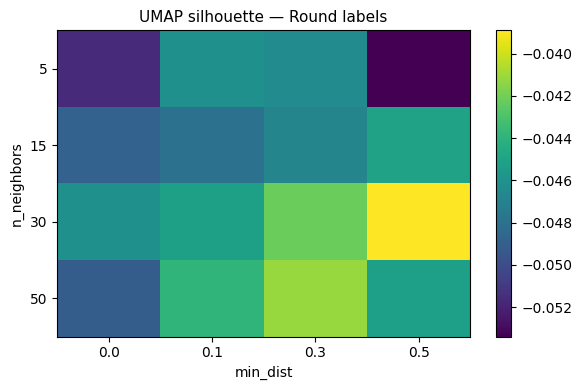

In [5]:
def umap_hyperparameter_search(X_scaled, meta) -> tuple[int, float, pd.DataFrame]:
    round_series = pd.to_numeric(meta["Round"], errors="coerce")
    valid_mask = round_series.notna().values
    round_labels = round_series[valid_mask].astype(int).values
    if len(np.unique(round_labels)) < 2:
        raise ValueError(
            "Round labels must contain at least 2 classes for silhouette scoring. "
            "Could not parse enough valid values from column 'Round'."
        )
    results = []

    print("[UMAP]  Hyperparameter grid search…")
    for nn in N_NEIGHBORS_GRID:
        for md in MIN_DIST_GRID:
            reducer = umap_pkg.UMAP(
                n_components=2, n_neighbors=nn, min_dist=md,
                metric="euclidean", random_state=RANDOM_STATE, low_memory=False,
            )
            emb = reducer.fit_transform(X_scaled)
            sil = silhouette_score(emb[valid_mask], round_labels, metric="euclidean")
            results.append({"n_neighbors": nn, "min_dist": md, "silhouette": sil})
            print(f"         n_neighbors={nn:3d}  min_dist={md:.1f}  sil={sil:.4f}")

    results_df = pd.DataFrame(results)
    best = results_df.loc[results_df["silhouette"].idxmax()]
    print(f"[UMAP]  Best → n_neighbors={int(best.n_neighbors)}, "
          f"min_dist={best.min_dist:.1f}  (sil={best.silhouette:.4f})")
    
    pivot = results_df.pivot(index="n_neighbors", columns="min_dist", values="silhouette")
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(MIN_DIST_GRID)));    ax.set_xticklabels(MIN_DIST_GRID)
    ax.set_yticks(range(len(N_NEIGHBORS_GRID))); ax.set_yticklabels(N_NEIGHBORS_GRID)
    ax.set_xlabel("min_dist");  ax.set_ylabel("n_neighbors")
    ax.set_title("UMAP silhouette — Round labels", fontsize=11)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

    return int(best.n_neighbors), float(best.min_dist), results_df

best_nn, best_md, hparam_df = umap_hyperparameter_search(X_scaled, meta)


## Fit UMAP with best parameters

In [6]:
def fit_umap(X_scaled, n_neighbors, min_dist, tag=""):
    reducer = umap_pkg.UMAP(
        n_components=2, n_neighbors=n_neighbors, min_dist=min_dist,
        metric="euclidean", random_state=RANDOM_STATE, low_memory=False,
    )
    emb = reducer.fit_transform(X_scaled)
    print(f"[UMAP{tag}]  shape={emb.shape}  "
          f"n_neighbors={n_neighbors}  min_dist={min_dist}")
    return emb, reducer

X_umap, umap_model = fit_umap(X_scaled, best_nn, best_md)

[UMAP]  shape=(312, 2)  n_neighbors=30  min_dist=0.5


## Function to plot visualizations based on various embeddings

In [7]:
def plot_umap_custom(
    embedding,
    df,
    column,
    title,
    color_map=None,
    marker_map=None
):
    def _map_lookup(mapping, value, default) -> str:
        if mapping is None:
            return default
        if pd.isna(value):
            return default
        if value in mapping:
            return mapping[value]

        # Try robust fallbacks for numpy/pandas numeric dtypes and string-encoded keys.
        try:
            value_int = int(value)
            if value_int in mapping:
                return mapping[value_int]
        except (TypeError, ValueError):
            pass

        value_str = str(value).strip()
        if value_str in mapping:
            return mapping[value_str]

        return default

    plt.figure()

    values = df[column]

    # If categories
    if color_map is not None:
        for val in values.dropna().unique():
            idx = values == val

            color = _map_lookup(color_map, val, "gray")
            marker = _map_lookup(marker_map, val, "o")

            plt.scatter(
                embedding[idx, 0],
                embedding[idx, 1],
                s=10,
                c=color,
                marker=marker,
                label=str(val)
            )

        plt.legend()

    else:
        # continuous
        sc = plt.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c=values,
            s=10
        )
        plt.colorbar(sc)

    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.show()

## Colouring embeddings by Round, Phase, Role and Cohort

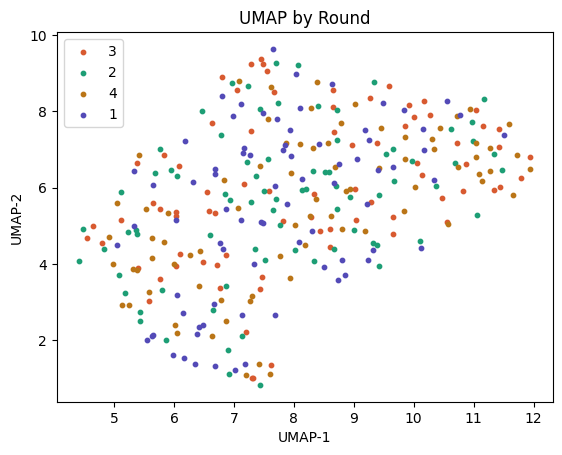

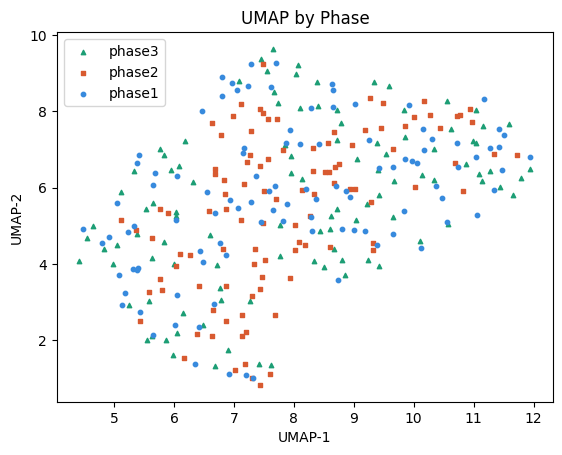

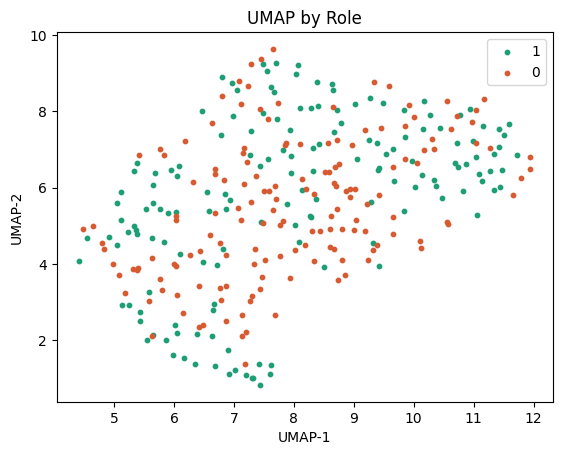

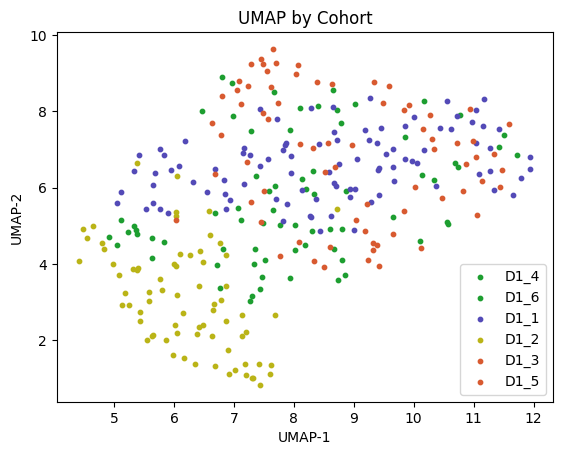

In [8]:
# Colouring embeddings by rounds
plot_umap_custom(
    X_umap,
    data,
    column="Round",
    title="UMAP by Round",
    color_map=ROUND_COLORS
)

# Colouring embeddings by phases
plot_umap_custom(
    X_umap,
    data,
    column="Phase",
    title="UMAP by Phase",
    color_map=PHASE_COLORS,
    marker_map=PHASE_MARKERS
)

# Colouring embeddings by roles
plot_umap_custom(
    X_umap,
    data,
    column="Puzzler",
    title="UMAP by Role",
    color_map=ROLE
)

# Colouring embeddings by cohorts
plot_umap_custom(
    X_umap,
    data,
    column="Cohort",
    title="UMAP by Cohort",
    color_map=COHORT
)

## Plot colourings by embeddings of physiological signals

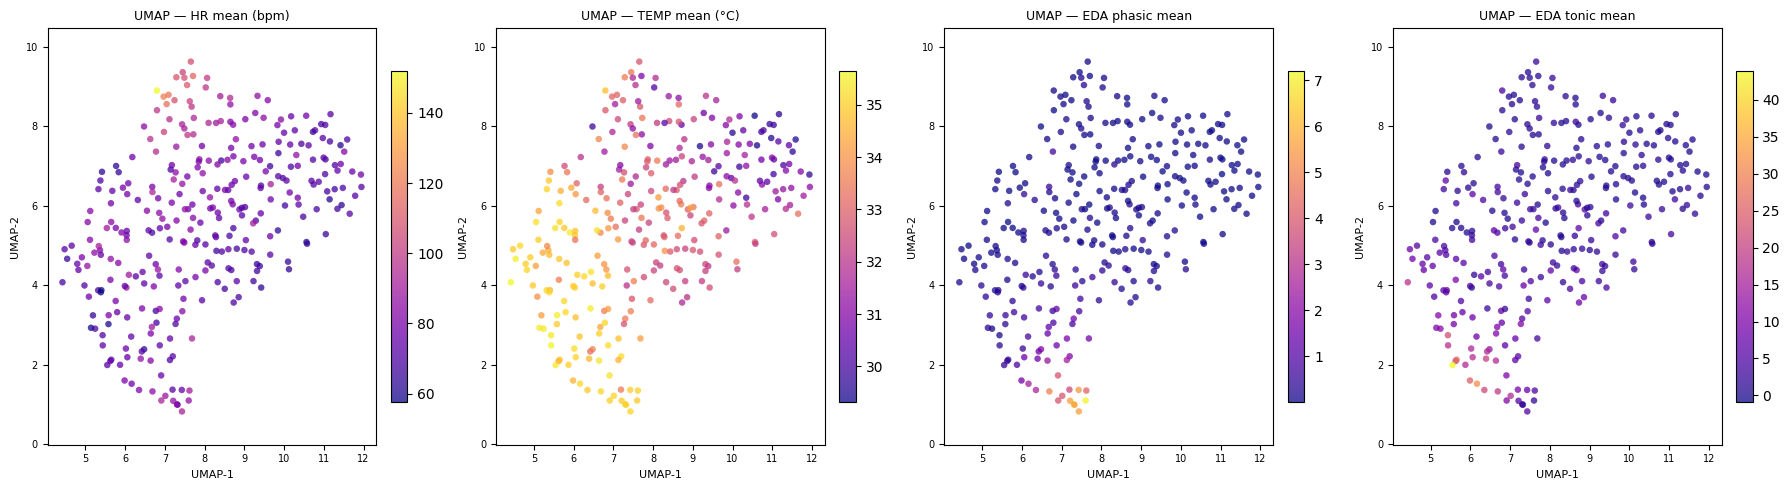

In [9]:
def plot_signal_panels(X_umap: np.ndarray, meta: pd.DataFrame) -> None:
    """
    Four panels: UMAP coloured by mean of each biosignal modality.
    Interprets what the UMAP axes physically represent.
    """
    signals = {
        "HR mean (bpm)":   "HR_TD_Mean",
        "TEMP mean (°C)":  "TEMP_TD_Mean",
        "EDA phasic mean": "EDA_TD_P_Mean",
        "EDA tonic mean":  "EDA_TD_T_Mean",
    }
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    for ax, (label, col) in zip(axes, signals.items()):
        vals = meta[col].values if col in meta.columns else np.zeros(len(meta))
        sc = ax.scatter(X_umap[:, 0], X_umap[:, 1],
                        c=vals, cmap="plasma", s=22, alpha=0.75, linewidths=0)
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f"UMAP — {label}", fontsize=9)
        ax.set_xlabel("UMAP-1", fontsize=8); ax.set_ylabel("UMAP-2", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_aspect("equal", adjustable="datalim")
    plt.tight_layout()
    plt.show()

plot_signal_panels(X_umap, data)


## Apply k-means clustering on UMAP embeddings

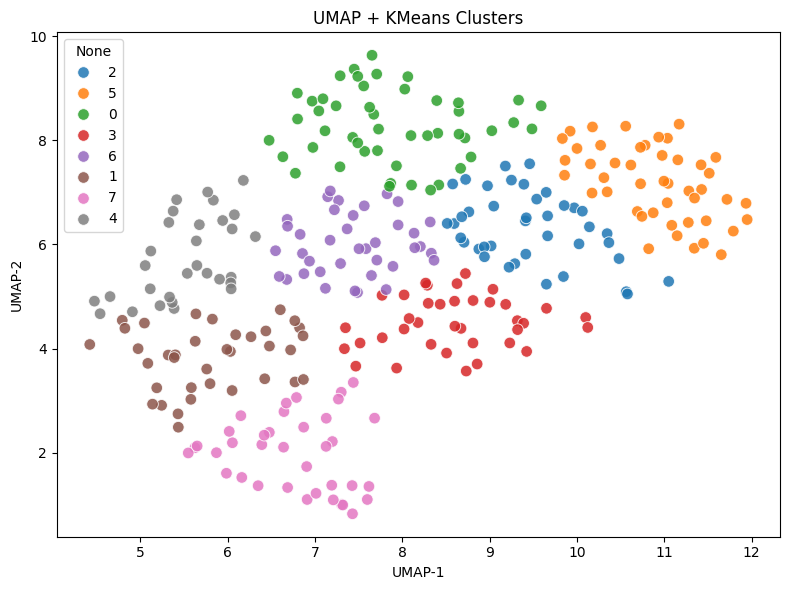

In [10]:
def plot_umap(embedding, labels, title, palette=None, markers=None, legend=True) -> None:
    plt.figure(figsize=(8, 6))

    labels = pd.Series(labels).astype(str)

    if markers is not None:
        sns.scatterplot(
            x=embedding[:, 0],
            y=embedding[:, 1],
            hue=labels,
            style=labels,
            palette=palette,
            markers=markers,
            s=70,
            alpha=0.85
        )
    else:
        sns.scatterplot(
            x=embedding[:, 0],
            y=embedding[:, 1],
            hue=labels,
            palette=palette,
            s=70,
            alpha=0.85
        )

    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")

    if not legend:
        plt.legend([], [], frameon=False)

    plt.tight_layout()
    plt.show()

kmeans = KMeans(n_clusters=8, random_state=42)
clusters = kmeans.fit_predict(X_umap)

plot_umap(
    X_umap,
    clusters,
    "UMAP + KMeans Clusters"
)


## Apply k-means clustering on scaled original data to examine if there are cluster patterns in the original data

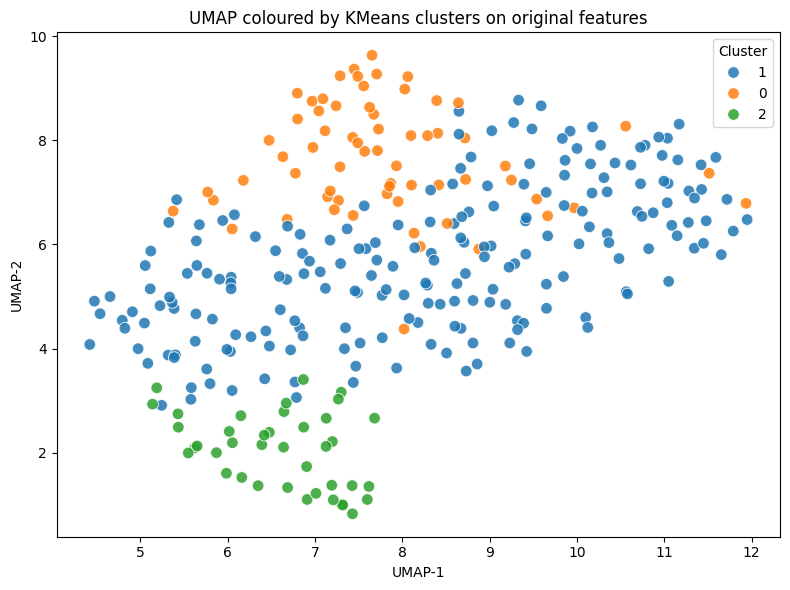

In [11]:
clusters = KMeans(n_clusters=3, random_state=42).fit(X_scaled)
data["Cluster"] = clusters.labels_
plot_umap(
    X_umap,
    data["Cluster"],
    "UMAP coloured by KMeans clusters on original features"
)
